# IoTSpy — ML Risk Scorer (Sample)

Train a **LightGBM** classifier to score captured requests by risk across three tags:
`DataBroker`, `ExfiltrationRisk`, and `PiiDetected`.

**Goal:** augment the static rule-v1 heuristics with a calibrated continuous risk score that
generalises to hosts not in the broker domain list.

**Prerequisites:** run `00_generate_sample_data.ipynb` first.

**Output:** `../../models/risk_scorer_broker.lgb` + feature manifest JSON.

---
### Why `scale_pos_weight` instead of SMOTE for the final model?

SMOTE oversamples the minority class to 50/50 during training. This shifts the model's
internal prior, so `predict_proba` is deflated on real imbalanced data even when the
decision boundary is correct (high ROC-AUC but all scores below 0.5).  
`scale_pos_weight = n_neg/n_pos` tells LightGBM to upweight positive examples without
resampling, preserving a well-calibrated probability output.

In [1]:
from pathlib import Path
import json, math, re
from collections import Counter
import ipaddress

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
import lightgbm as lgb

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

DATA_PATH  = Path("../data/sample_captures.parquet")
MODEL_DIR  = Path("../../models")
MODEL_DIR.mkdir(exist_ok=True)

assert DATA_PATH.exists(), f"Run 00_generate_sample_data.ipynb first"

df = pd.read_parquet(DATA_PATH)
if "timestamp" not in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True)
df["tag_list"]    = df["tags"].apply(json.loads)
df["rule_risk_score"] = df.get("risk_score", pd.Series(np.zeros(len(df)), index=df.index)).fillna(0.0)

print(f"Loaded {len(df):,} rows")
print(f"Rule-v1 scores > 0: {(df['rule_risk_score'] > 0).sum():,}")

Loaded 2,200 rows
Rule-v1 scores > 0: 1,298


## 1  Feature engineering

In [2]:
# ── column name helpers (works with both DB and Parquet schemas) ──────────────
def col(preferred, fallback):
    return preferred if preferred in df.columns else fallback

host_col    = col("host",               "Host")
port_col    = col("port",               "Port")
method_col  = col("method",             "Method")
path_col    = col("path",               "Path")
status_col  = col("status_code",        "StatusCode")
tls_col     = col("is_tls",             "IsTls")
cipher_col  = col("tls_cipher_suite",   "TlsCipherSuite")
req_sz_col  = col("request_body_size",  "RequestBodySize")
resp_sz_col = col("response_body_size", "ResponseBodySize")
dur_col     = col("duration_ms",        "DurationMs")
req_h_col   = col("request_headers",    "RequestHeaders")
resp_h_col  = col("response_headers",   "ResponseHeaders")

# ── helper functions ──────────────────────────────────────────────────────────
def shannon_entropy(s: str) -> float:
    if not s: return 0.0
    c, n = Counter(s), len(s)
    return -sum((v/n)*math.log2(v/n) for v in c.values())

def host_is_ip(h: str) -> int:
    try: ipaddress.ip_address(str(h)); return 1
    except ValueError: return 0

WEAK_CIPHERS   = {"rc4", "3des", "des", "null", "export", "anon"}
MODERN_CIPHERS = {"tls_aes_128_gcm", "tls_aes_256_gcm", "chacha20",
                  "ecdhe_rsa_aes_128_gcm", "ecdhe_rsa_aes_256_gcm"}

def cipher_strength(c: str) -> int:
    if not c: return 0
    lc = c.lower()
    if any(w in lc for w in WEAK_CIPHERS):   return 0
    if any(m in lc for m in MODERN_CIPHERS): return 2
    return 1

def parse_headers(h) -> dict:
    if not h or (isinstance(h, float) and math.isnan(h)): return {}
    if isinstance(h, dict): return {k.lower(): v for k, v in h.items()}
    try: return {k.lower(): v for k, v in json.loads(h).items()}
    except Exception: return {}

AD_PATH_RE = re.compile(
    r"/(ad|ads|bid|click|collect|event|telemetry|pixel|beacon|"
    r"impression|rtb|sdk|analytics|log|report|metric|track|attribution)",
    re.IGNORECASE,
)

req_hdrs  = df[req_h_col].apply(parse_headers)
resp_hdrs = df[resp_h_col].apply(parse_headers)

# ── build feature DataFrame ───────────────────────────────────────────────────
feat = pd.DataFrame(index=df.index)

# Use ground-truth broker flag if present, otherwise derive from domain list
if "is_known_broker" in df.columns:
    feat["is_broker"] = df["is_known_broker"].astype(float)
else:
    from analytics_helpers import is_broker_domain  # define inline above if needed
    feat["is_broker"] = df[host_col].apply(lambda h: float(is_broker_domain(h)))

feat["host_is_ip"]          = df[host_col].fillna("").apply(host_is_ip)
feat["dns_entropy"]         = df[host_col].fillna("").apply(shannon_entropy)
feat["host_len"]            = df[host_col].fillna("").apply(len)
feat["host_depth"]          = df[host_col].fillna("").apply(lambda h: h.count("."))
feat["host_subdomain_depth"]= df[host_col].fillna("").apply(lambda h: max(0, h.count(".")-1))

feat["is_tls"]              = df[tls_col].astype(int)
feat["tls_cipher_strength"] = df[cipher_col].fillna("").apply(cipher_strength)

feat["method_post"]         = (df[method_col] == "POST").astype(int)
feat["method_get"]          = (df[method_col] == "GET").astype(int)
feat["method_put"]          = (df[method_col] == "PUT").astype(int)
feat["is_standard_port"]    = df[port_col].isin({80, 443, 8080, 8443, 1883, 8883, 5683}).astype(int)

feat["req_size_log"]        = np.log1p(df[req_sz_col].fillna(0))
feat["resp_size_log"]       = np.log1p(df[resp_sz_col].fillna(0))
feat["duration_log"]        = np.log1p(df[dur_col].clip(lower=0).fillna(0))

feat["has_user_agent"]      = req_hdrs.apply(lambda h: int("user-agent" in h))
feat["has_authorization"]   = req_hdrs.apply(lambda h: int("authorization" in h))
feat["has_device_id_hdr"]   = req_hdrs.apply(
    lambda h: int(any("device" in k or "idfa" in k or "idfv" in k for k in h)))
feat["resp_is_json"]        = resp_hdrs.apply(
    lambda h: int("json" in h.get("content-type", "").lower()))
feat["resp_is_binary"]      = resp_hdrs.apply(
    lambda h: int(any(t in h.get("content-type", "").lower()
                      for t in ("octet-stream", "protobuf", "binary", "video", "mp4"))))

feat["path_ad_pattern"]     = df[path_col].fillna("").apply(lambda p: int(bool(AD_PATH_RE.search(p))))
feat["path_len"]            = df[path_col].fillna("").apply(len)
feat["path_depth"]          = df[path_col].fillna("").apply(lambda p: p.count("/"))
feat["has_query_string"]    = df[path_col].fillna("").apply(lambda p: int("?" in p))

feat["hour_of_day"]         = df["timestamp"].dt.hour

feat["status_2xx"]          = ((df[status_col] >= 200) & (df[status_col] < 300)).astype(int)
feat["status_4xx"]          = ((df[status_col] >= 400) & (df[status_col] < 500)).astype(int)
feat["status_5xx"]          = (df[status_col] >= 500).astype(int)

# Composite signal: large POST to a broker endpoint
feat["large_post_to_broker"] = (
    (feat["method_post"] == 1) & (feat["is_broker"] == 1) & (feat["req_size_log"] > 6)
).astype(int)

FEATURE_COLS = feat.columns.tolist()
X = feat[FEATURE_COLS].astype(float)
print(f"Built {len(FEATURE_COLS)} features")

Built 29 features


## 2  Build labels

In [3]:
TAGS = ["DataBroker", "ExfiltrationRisk", "PiiDetected"]
for tag in TAGS:
    df[f"label_{tag}"] = df["tag_list"].apply(lambda t: int(tag in t))
    pos = df[f"label_{tag}"].sum()
    print(f"{tag:<22}  positives: {pos:>5,}  ({pos/len(df)*100:.1f}%)")

DataBroker              positives: 1,298  (59.0%)
ExfiltrationRisk        positives:    46  (2.1%)
PiiDetected             positives:    93  (4.2%)


## 3  DataBroker classifier

In [4]:
y_broker = df["label_DataBroker"].values
n_neg, n_pos = (y_broker == 0).sum(), (y_broker == 1).sum()
print(f"Class balance — 0: {n_neg:,}  1: {n_pos:,}  (ratio {n_neg/n_pos:.1f}:1)")

# Cross-val with SMOTE pipeline for unbiased evaluation
cv_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=min(4, n_pos - 1))),
    ("clf",   lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                  num_leaves=31, min_child_samples=10,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, verbose=-1)),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba_cv = cross_val_predict(cv_pipe, X, y_broker, cv=cv, method="predict_proba")[:, 1]

print(classification_report(y_broker, (y_proba_cv >= 0.5).astype(int),
                             target_names=["Other", "DataBroker"]))
print(f"ROC-AUC (5-fold CV): {roc_auc_score(y_broker, y_proba_cv):.4f}")

# Final model with scale_pos_weight for well-calibrated predict_proba
broker_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=n_neg / n_pos,
    random_state=42, verbose=-1,
)
broker_model.fit(X, y_broker)

Class balance — 0: 902  1: 1,298  (ratio 0.7:1)


              precision    recall  f1-score   support

       Other       1.00      1.00      1.00       902
  DataBroker       1.00      1.00      1.00      1298

    accuracy                           1.00      2200
   macro avg       1.00      1.00      1.00      2200
weighted avg       1.00      1.00      1.00      2200

ROC-AUC (5-fold CV): 1.0000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


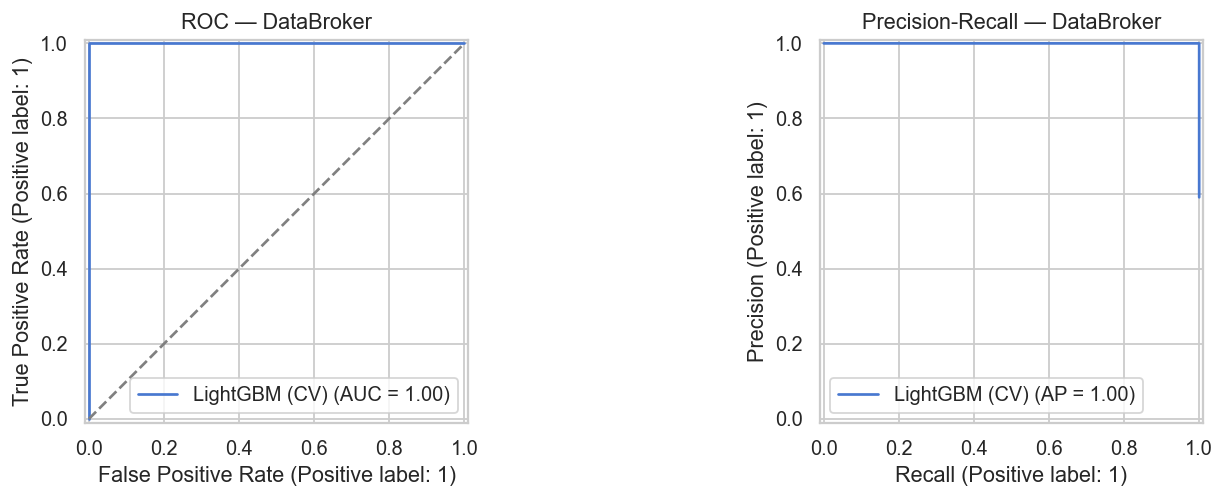

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_broker, y_proba_cv, ax=axes[0], name="LightGBM (CV)")
axes[0].plot([0,1],[0,1],"--",color="gray")
axes[0].set_title("ROC — DataBroker")
PrecisionRecallDisplay.from_predictions(y_broker, y_proba_cv, ax=axes[1], name="LightGBM (CV)")
axes[1].set_title("Precision-Recall — DataBroker")
plt.tight_layout()
plt.show()

## 4  Feature importance

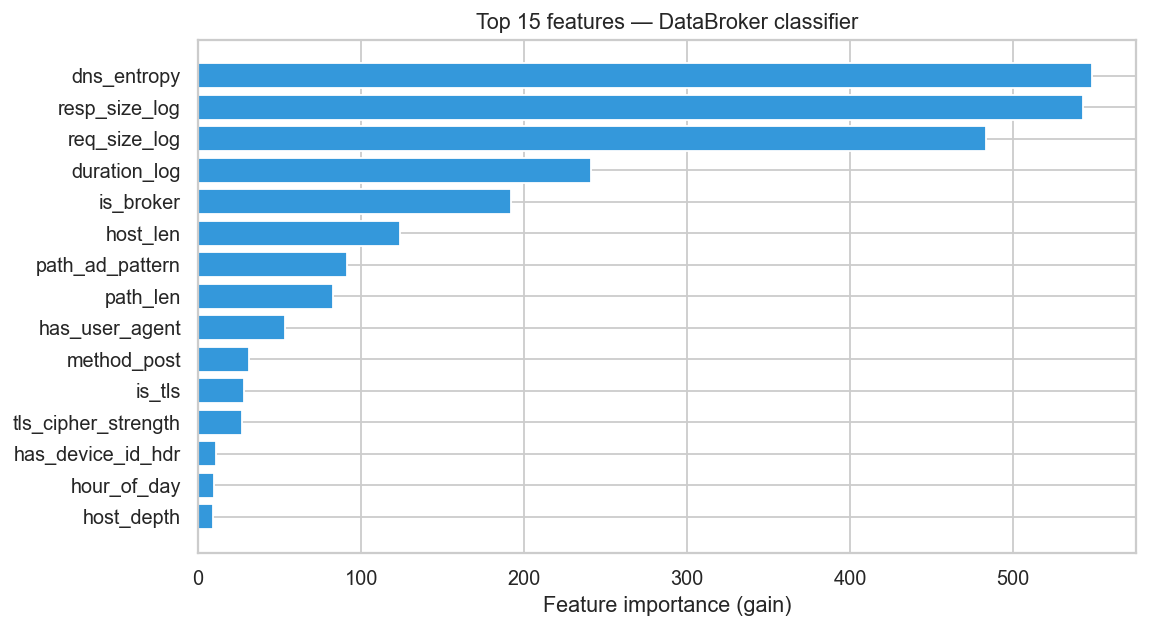

In [6]:
imp = pd.Series(broker_model.feature_importances_, index=FEATURE_COLS)
top = imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index[::-1], top.values[::-1], color="#3498db")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 15 features — DataBroker classifier")
plt.tight_layout()
plt.show()

## 5  ExfiltrationRisk classifier

In [7]:
y_exfil   = df["label_ExfiltrationRisk"].values
n_pos_e   = y_exfil.sum()
n_neg_e   = (y_exfil == 0).sum()

if n_pos_e >= 10:
    exfil_pipe = ImbPipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=min(4, n_pos_e - 1))),
        ("clf",   lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                      num_leaves=31, min_child_samples=10,
                                      subsample=0.8, colsample_bytree=0.8,
                                      random_state=42, verbose=-1)),
    ])
    y_exfil_proba = cross_val_predict(
        exfil_pipe, X, y_exfil,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method="predict_proba"
    )[:, 1]
    print(classification_report(y_exfil, (y_exfil_proba >= 0.5).astype(int),
                                 target_names=["Other", "ExfiltrationRisk"]))
    print(f"ROC-AUC: {roc_auc_score(y_exfil, y_exfil_proba):.4f}")

    exfil_model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=n_neg_e / n_pos_e,
        random_state=42, verbose=-1,
    )
    exfil_model.fit(X, y_exfil)
else:
    print(f"Only {n_pos_e} ExfiltrationRisk positives — capture more data to train reliably.")
    exfil_model = None

                  precision    recall  f1-score   support

           Other       1.00      1.00      1.00      2154
ExfiltrationRisk       0.98      1.00      0.99        46

        accuracy                           1.00      2200
       macro avg       0.99      1.00      0.99      2200
    weighted avg       1.00      1.00      1.00      2200

ROC-AUC: 1.0000


## 6  Composite risk score

With weights `{DataBroker: 0.4, ExfiltrationRisk: 0.4, PiiDetected: 0.2}` a single strong
signal maxes at **0.4**, two signals at **0.8**.  
Use **0.3** as the flag threshold — any request where the model is confident about ≥1 tag.

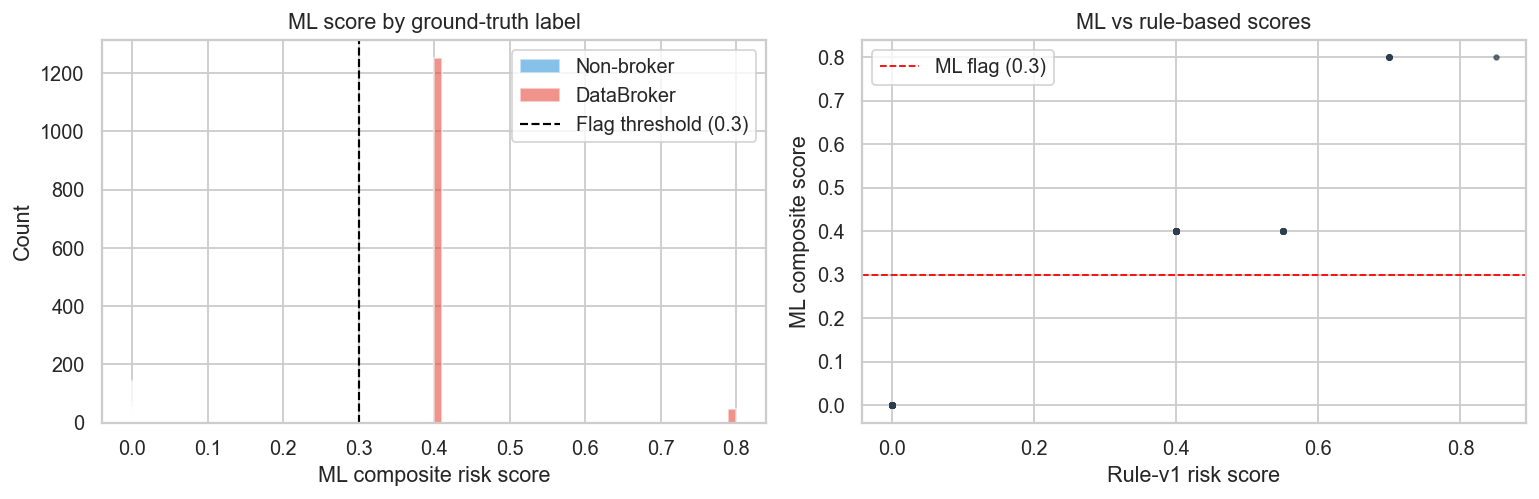

ML flagged (> 0.3):   1,298
Rule-v1 flagged (> 0): 1,298

ML-only flags (missed by rule-v1): 0


In [8]:
WEIGHTS       = {"DataBroker": 0.4, "ExfiltrationRisk": 0.4, "PiiDetected": 0.2}
FLAG_THRESHOLD = 0.3

p_broker = broker_model.predict_proba(X)[:, 1]
p_exfil  = exfil_model.predict_proba(X)[:, 1] if exfil_model else np.zeros(len(X))

composite    = WEIGHTS["DataBroker"] * p_broker + WEIGHTS["ExfiltrationRisk"] * p_exfil
rule_scores  = df["rule_risk_score"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(composite[y_broker == 0], bins=40, alpha=0.6, label="Non-broker", color="#3498db")
axes[0].hist(composite[y_broker == 1], bins=40, alpha=0.6, label="DataBroker", color="#e74c3c")
axes[0].axvline(FLAG_THRESHOLD, color="black", linestyle="--", lw=1.2,
                label=f"Flag threshold ({FLAG_THRESHOLD})")
axes[0].set_xlabel("ML composite risk score")
axes[0].set_ylabel("Count")
axes[0].set_title("ML score by ground-truth label")
axes[0].legend()

axes[1].scatter(rule_scores, composite, alpha=0.3, s=6, color="#2c3e50")
axes[1].axhline(FLAG_THRESHOLD, color="red", linestyle="--", lw=1,
                label=f"ML flag ({FLAG_THRESHOLD})")
axes[1].set_xlabel("Rule-v1 risk score")
axes[1].set_ylabel("ML composite score")
axes[1].set_title("ML vs rule-based scores")
axes[1].legend()

plt.tight_layout()
plt.show()

ml_flagged   = (composite > FLAG_THRESHOLD).sum()
rule_flagged = (rule_scores > 0).sum()
print(f"ML flagged (> {FLAG_THRESHOLD}):   {ml_flagged:,}")
print(f"Rule-v1 flagged (> 0): {rule_flagged:,}")

# Requests flagged by ML but missed by rules
novel = df[(composite > FLAG_THRESHOLD) & (rule_scores == 0)]
print(f"\nML-only flags (missed by rule-v1): {len(novel)}")
if len(novel):
    print(novel[[host_col, method_col, path_col, req_sz_col]].head(15).to_string(index=False))

## 7  Save model

In [9]:
import json as _json
import lightgbm as _lgb
import numpy as _np

lgb_path = MODEL_DIR / "risk_scorer_broker.lgb"
broker_model.booster_.save_model(str(lgb_path))
(MODEL_DIR / "risk_scorer_broker_features.json").write_text(
    _json.dumps(FEATURE_COLS, indent=2)
)
print(f"Model saved   → {lgb_path}")
print(f"Features JSON → {MODEL_DIR}/risk_scorer_broker_features.json")

# Verify round-trip
loaded = _lgb.Booster(model_file=str(lgb_path))
broker_idx    = _np.where(y_broker == 1)[0][:3]
non_broker_idx = _np.where(y_broker == 0)[0][:3]
check_idx = _np.concatenate([broker_idx, non_broker_idx])
check_proba = loaded.predict(X.values[check_idx])

print("\nSmoke test:")
print(f"{'Host':<45} {'Label':>8} {'p_broker':>10}")
print("-" * 65)
for idx, p in zip(check_idx, check_proba):
    print(f"{df.iloc[idx][host_col][:44]:<45} "
          f"{'broker' if y_broker[idx] else 'other':>8} {p:>10.4f}")

Model saved   → ../../models/risk_scorer_broker.lgb
Features JSON → ../../models/risk_scorer_broker_features.json

Smoke test:
Host                                             Label   p_broker
-----------------------------------------------------------------
bid.rtbfusion.example.com                       broker     1.0000
log.behavioriq.example.com                      broker     1.0000
ads.quantumreach.example.net                    broker     1.0000
cdn.playvault.example.com                        other     0.0000
sync.vocalize-home.example.com                   other     0.0000
connectivity.example-check.com                   other     0.0000
